<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Flexão de vigas constituídas por vários materiais

### Problema 2

Uma viga de madeira com secção transversal de 150 $\times$ 250 mm $^2$ foi reforçada com placas de aço conforme representado na figura. O módulo de elasticidade da madeira é de 10 GPa e o do aço é 200 GPa. Sabendo que a viga se encontra fletida em torno de um eixo horizontal devido à atuação de um momento fletor igual a 20 kN.m, determine a tensão máxima na madeira e no aço.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au02/P2/MSII_Au02_P2.png"
style="max-height: 100%; max-width: 100%;"/>

### Resolução

Considere-se a  viga composta em altura de aço e alumínio com os seguintes dados:

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)


# data structure, units: N, mm, MPa
# Create an empty class

from collections import namedtuple

# Declaring namedtuple()
# unit: mm, N, MPa
Dados = namedtuple('Dados',['Emad','Eaco','Lmad','hmad','Laco','haco','M'])
d = Dados(10.*1e3,200.*1e3,150.,250.,10.,50.,20.*1e6)
Amad = d.Lmad*d.hmad
print(f' Wood section : {d.Lmad:.1f} mm x {d.hmad:.1f} mm = {Amad:.1f} mm²')
Aaco = d.Laco*d.haco
print(f'Steel section :  {d.Laco:.1f} mm x {d.haco:.1f}  mm = {Aaco:.1f}   mm²')

 Wood section : 150.0 mm x 250.0 mm = 37500.0 mm²
Steel section :  10.0 mm x 50.0  mm = 500.0   mm²


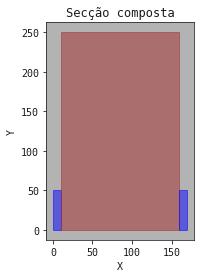

In [2]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((0, 0), d.Laco, d.haco,color="blue",alpha=0.5))
ax.add_patch(Rectangle((d.Laco, 0), d.Lmad, d.hmad,color="brown",alpha=0.5))
ax.add_patch(Rectangle((d.Laco+d.Lmad, 0), d.Laco, d.haco,color="blue",alpha=0.5))
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Secção composta")
ax.set_aspect('equal')
plt.show()

### Secção homogénea equivalente

É possível usar as expressões da flexão para um material homogéneo no contexto de vigas constitutivas por vários materiais (composição em altura ou em largura), fazendo alusão ao conceito de viga homogénea equivalente. Esta é obtida escolhendo um dos materiais e substituindo os demais pelo material escolhido. Naturalmente, por uma questão de equivalência pelo critério da flexão, torna-se necessário alterar as dimensões geométricas das regiões transformadas, usando para tal um rácio dado pela razão entre os módulos de elasticidade dos materiais (o problema da flexão é tipicamente pilotado por este parâmetro mecânico).

Sem perda de generalidade, escolha-se o aço como material de referência. Torna-se assim necessário subtituir a região de alumínio por aço, dando origem a uma secção transformada (homogénea de aço).

### Secção homogéna de madeira

Razão de módulos:

\begin{equation*}
n_{i/j} = \frac{E_\textrm{i}}{E_\textrm{j}}
\quad\Rightarrow\quad
n = \frac{E_\textrm{Aco}}{E_\textrm{Mad}}
\end{equation*}

In [3]:
rMods = d.Eaco/d.Emad
print(f'Razão de módulos, n = E.Aco /E.Mad = {rMods:.1f}')

Razão de módulos, n = E.Aco /E.Mad = 20.0


A geometria da secção inicial composta deve ser alterada para garantir o problema equivalente em flexão. A substituição da região de aço por madeira conduz a um aumento da secção local, de acordo com a razão de módulos.

\begin{equation*}
l_\textrm{Aco2Mad} = n \cdot l_\textrm{Aco} = \frac{E_\textrm{Aco}}{E_\textrm{Mad}} \cdot l_\textrm{Aco}
\end{equation*}

In [4]:
Laco2mad = d.Laco*rMods
print(f'Original l (Aco) : {d.Laco:.1f} mm < Transformed l (Madeira) : {Laco2mad:.1f} mm')

Original l (Aco) : 10.0 mm < Transformed l (Madeira) : 200.0 mm


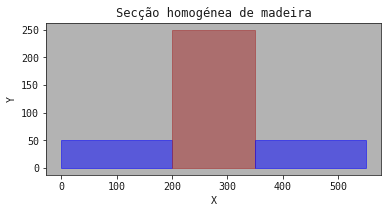

In [5]:

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((0, 0), Laco2mad, d.haco,color="blue",alpha=0.5))
ax.add_patch(Rectangle((Laco2mad, 0), d.Lmad, d.hmad,color="brown",alpha=0.5))
ax.add_patch(Rectangle((Laco2mad+d.Lmad, 0), Laco2mad, d.haco,color="blue",alpha=0.5))
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Secção homogénea de madeira")
ax.set_aspect('equal')
plt.show()
plt.show()

- Posição do eixo neutro

É fundamental conhecer a posição do eixo neutro, nomeadamente para determinar a distribuição do perfil de tensões.

A secção tranformada tem um plano de simetria vertical, pelo que a abscissa é bem determinada. A posição vertical do centroide, em relação à base da secção por exemplo, deve ser contudo cálculada:

\begin{equation*}
\overline{y} = \sum_i \frac{A_i\overline{y}_i}{A_i}
\quad\Rightarrow\quad
\overline{y} = \frac{A_\textrm{mad}\overline{y}_\textrm{mad} + 2(n A_\textrm{aco}\overline{y}_\textrm{aco})}{A_\textrm{mad} + 2(n A_\textrm{aco})}
\end{equation*}

In [6]:
ycmad = d.hmad/2
print(f'area (wood) : A = {Amad:.1f} mm²; yc = {ycmad:.1f} mm')

ycaco = d.haco/2
print(f'area transf. (aco2mad) : A = {rMods*Aaco:.1f} mm²; yc = {ycaco:.1f} mm')

print(f'\ncal aux. : (Ay)mad = {Amad*ycmad:.1f} mm²')
print(f'cal aux. : (n*Ay)acu2mad = {rMods*Aaco*ycaco:.1f} mm²')

ychomog = (Amad*ycmad + 2*rMods*Aaco*ycaco)/(Amad+2*rMods*Aaco)
print(f'\nyc (transformed section) = {ychomog:.2f} mm')

area (wood) : A = 37500.0 mm²; yc = 125.0 mm
area transf. (aco2mad) : A = 10000.0 mm²; yc = 25.0 mm

cal aux. : (Ay)mad = 4687500.0 mm²
cal aux. : (n*Ay)acu2mad = 250000.0 mm²

yc (transformed section) = 90.22 mm


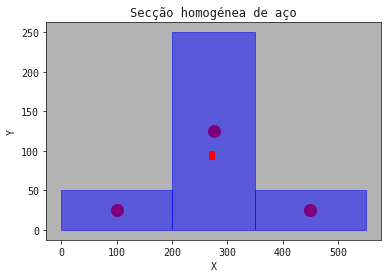

In [7]:
fig, ax = plt.subplots()
ax.scatter([Laco2mad/2,Laco2mad+d.Lmad/2,Laco2mad+d.Lmad+Laco2mad/2],[d.haco/2,d.hmad/2,d.haco/2],color="red",marker="o",linewidth=7)
ax.add_patch(Rectangle((0, 0), Laco2mad, d.haco,color="blue",alpha=0.5))
ax.add_patch(Rectangle((Laco2mad, 0), d.Lmad, d.hmad,color="blue",alpha=0.5))
ax.add_patch(Rectangle((Laco2mad+d.Lmad, 0), Laco2mad, d.haco,color="blue",alpha=0.5))
ax.add_patch(Rectangle((Laco2mad+d.Lmad/2+1., ychomog), -10, 10,color="red"))
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Secção homogénea de aço")
plt.show()

> - Momento de inércia

O momento de inércia da secção transformada pode também ser obtido pela combinação linear dos momentos de inércia das regiões elementares da secção:

\begin{equation*}
I_t = I_\textrm{mad} + \sum_{i = 1}^2 nI_\textrm{aco,i} = \underbrace{I_1 + A_1 d_1²}_{\textrm{mad}} + 2[\underbrace{n(I_2 + A_2 d_2²)}_{\textrm{aco}}]
\end{equation*}

com

\begin{equation*}
d_1 = |h_1/2-\overline{y}|
\quad\wedge\quad~
d_2 = |\overline{y}-(h_1/2)|
\end{equation*}

In [8]:
def irect(b,h):
    return b*h**3/12

d1 = d.hmad/2-ychomog
print(f'\nd1 = {d1:.2f} mm')
Imad = irect(d.Lmad,d.hmad) + Amad*d1**2
print(f'Iz (wood) = {Imad:.2f} mm⁴')

d2 = ychomog - d.haco/2
print(f'\nd2 = {d2:.2f} mm')
Iaco2mad = irect(rMods*d.Laco,d.haco) + rMods*Aaco*d2**2
print(f'Iz (aco2mad) = {Iaco2mad:.2f} mm⁴')

Itot = Imad + 2*Iaco2mad
print(f'\nIz (trans. section) = {Itot:.2f} mm⁴ = {Itot*1e-12:.2e} m⁴')


d1 = 34.78 mm
Iz (wood) = 240681120.04 mm⁴

d2 = 65.22 mm
Iz (aco2mad) = 87149495.90 mm⁴

Iz (trans. section) = 327830615.94 mm⁴ = 3.28e-04 m⁴


> Determine o tensão máxima na madeira e no aço

- Madeira:

\begin{equation*}
\sigma_\textrm{max}^\textrm{mad} = -\frac{M_f}{I_t}c
\quad\wedge\quad~
c = h_\textrm{mad} - \overline{y}
\end{equation*}

- Aço:

\begin{equation*}
\sigma_\textrm{max}^\textrm{aco} = -n\frac{M_f}{I_t}c
\quad\wedge\quad~
c = - \overline{y}
\end{equation*}

In [9]:
ymad_max = d.hmad - ychomog
print(f'\n     ymax (wood) = {ymad_max:.3f} mm')

sigmad_max = -d.M / Itot * ymad_max
print(f'Sxx,max (wood) = {sigmad_max:.2f} MPa')

yaco_max = - ychomog
print(f'\n     ymax (steel) = {yaco_max:.2f} mm')

sigaco_max = - rMods*d.M / Itot * yaco_max
print(f'Sxx,max (steel) = {sigaco_max:.2f} MPa')


     ymax (wood) = 159.783 mm
Sxx,max (wood) = -9.75 MPa

     ymax (steel) = -90.22 mm
Sxx,max (steel) = 110.08 MPa


---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>